# Benchmark 5: read-your-writes staleness
Write to the leader, then poll a follower's full-table SELECT until the row appears. Run `bench/05-read-your-writes.sh` first.

In [5]:
import sys
sys.path.insert(0, ".")
import matplotlib.pyplot as plt
from plot_style import load, agg


In [6]:
df = load("read-your-writes.csv")
df

,run,iteration,stalenessMs
0,1,1,19.9
1,1,2,20.9
2,1,3,17.2
3,1,4,18.6
4,1,5,19.2
...,...,...,...
195,10,16,19.8
196,10,17,18.4
197,10,18,18.7
198,10,19,18.7


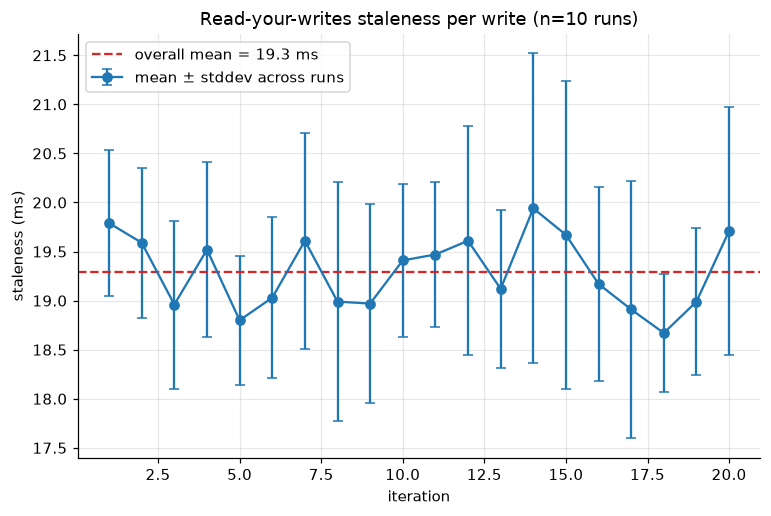

In [7]:
by_iteration = agg(df, ["iteration"], "stalenessMs")

fig, ax = plt.subplots()
ax.errorbar(by_iteration["iteration"], by_iteration["mean"], yerr=by_iteration["std"],
            marker="o", capsize=3, label="mean ± stddev across runs")
overall_mean = df["stalenessMs"].mean()
ax.axhline(overall_mean, color="tab:red", linestyle="--", label=f"overall mean = {overall_mean:.1f} ms")
ax.set_xlabel("iteration")
ax.set_ylabel("staleness (ms)")
ax.set_title(f"Read-your-writes staleness per write (n={df['run'].nunique()} runs)")
ax.legend()
plt.show()

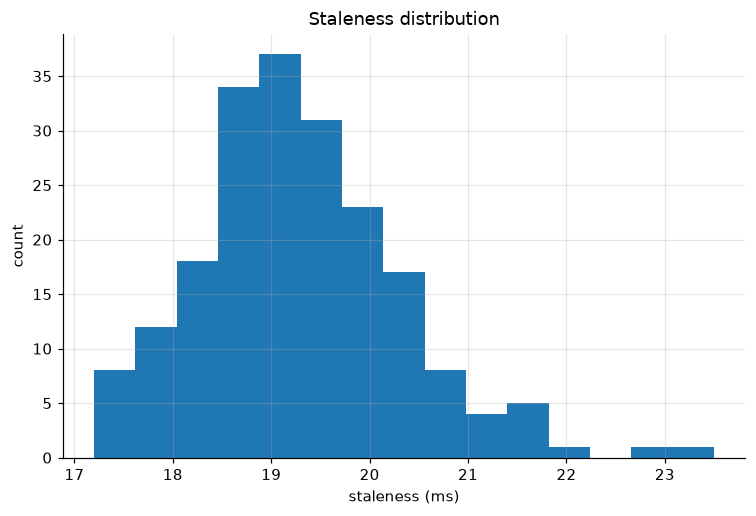

count    200.000000
mean      19.296500
std        1.036586
min       17.200000
25%       18.600000
50%       19.200000
75%       19.900000
max       23.500000
Name: stalenessMs, dtype: float64


In [8]:
fig, ax = plt.subplots()
ax.hist(df["stalenessMs"], bins=min(15, df['stalenessMs'].nunique()))
ax.set_xlabel("staleness (ms)")
ax.set_ylabel("count")
ax.set_title("Staleness distribution")
plt.show()
print(df["stalenessMs"].describe())